In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score, f1_score
)

print("PASSO 1: Carregando e Estruturando os Dados")

df = pd.read_csv("../data/WineQT.csv")

traducao_colunas = {
    'fixed acidity': 'acidez_fixa',
    'volatile acidity': 'acidez_volatil',
    'citric acid': 'acido_citrico',
    'residual sugar': 'acucar_residual',
    'chlorides': 'cloretos',
    'free sulfur dioxide': 'dioxido_enxofre_livre',
    'total sulfur dioxide': 'dioxido_enxofre_total',
    'density': 'densidade',
    'pH': 'ph',
    'sulphates': 'sulfatos',
    'alcohol': 'teor_alcoolico',
    'quality': 'qualidade'
}
df = df.rename(columns=traducao_colunas)

df['alta_qualidade'] = df['qualidade'].apply(lambda x: 1 if x >= 7 else 0)

print(df['alta_qualidade'].value_counts())

PASSO 1: Carregando e Estruturando os Dados
alta_qualidade
0    984
1    159
Name: count, dtype: int64


--- PASSO 2: Análise Exploratória (EDA) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   acidez_fixa            1143 non-null   float64
 1   acidez_volatil         1143 non-null   float64
 2   acido_citrico          1143 non-null   float64
 3   acucar_residual        1143 non-null   float64
 4   cloretos               1143 non-null   float64
 5   dioxido_enxofre_livre  1143 non-null   float64
 6   dioxido_enxofre_total  1143 non-null   float64
 7   densidade              1143 non-null   float64
 8   ph                     1143 non-null   float64
 9   sulfatos               1143 non-null   float64
 10  teor_alcoolico         1143 non-null   float64
 11  qualidade              1143 non-null   int64  
 12  Id                     1143 non-null   int64  
 13  alta_qualidade         1143 non-null   int64  
 14  taxa_enxofre

C:\Users\Victor\AppData\Local\Temp\ipykernel_11588\1391322000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='qualidade', data=df, palette='viridis')


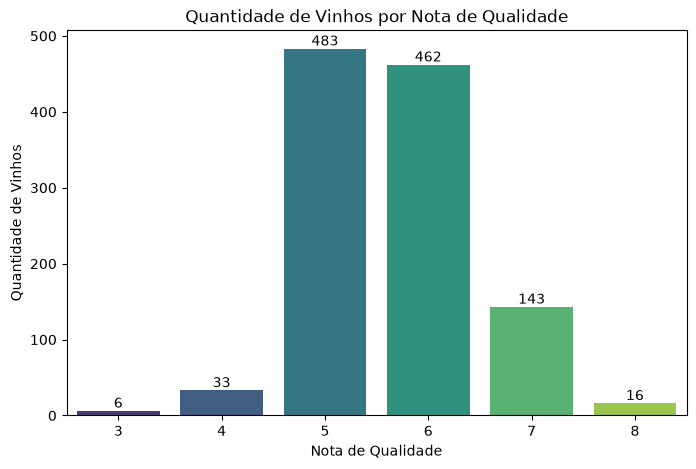

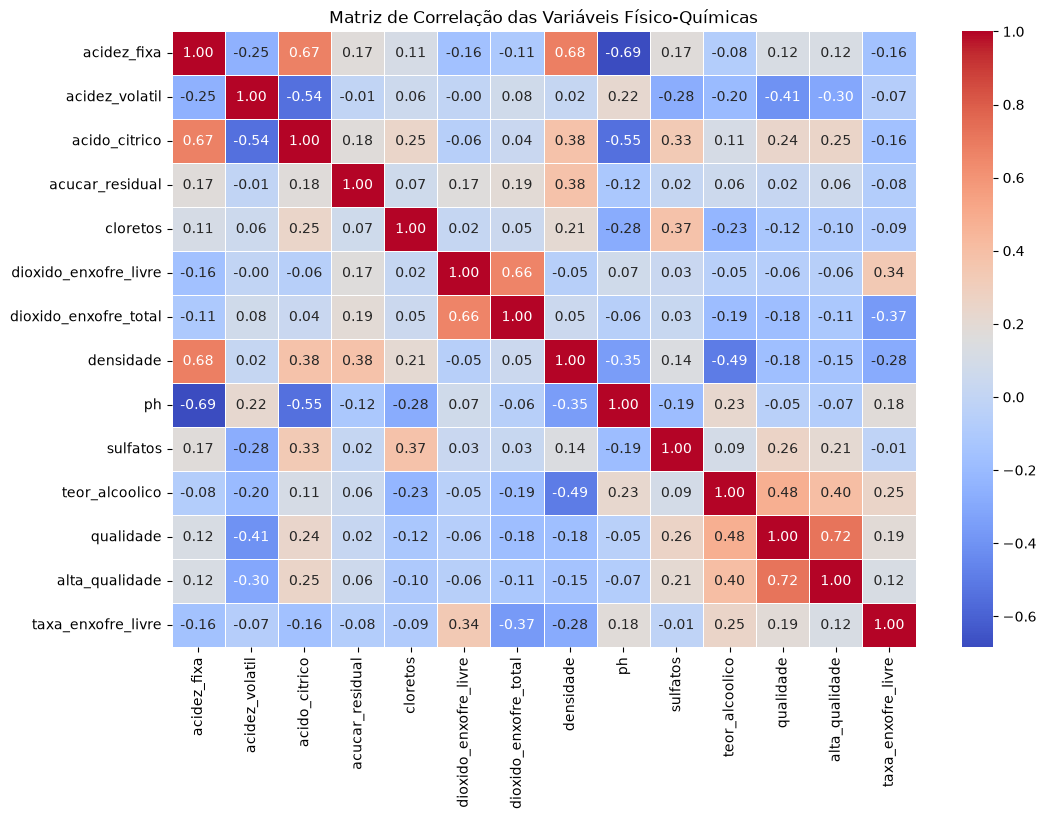

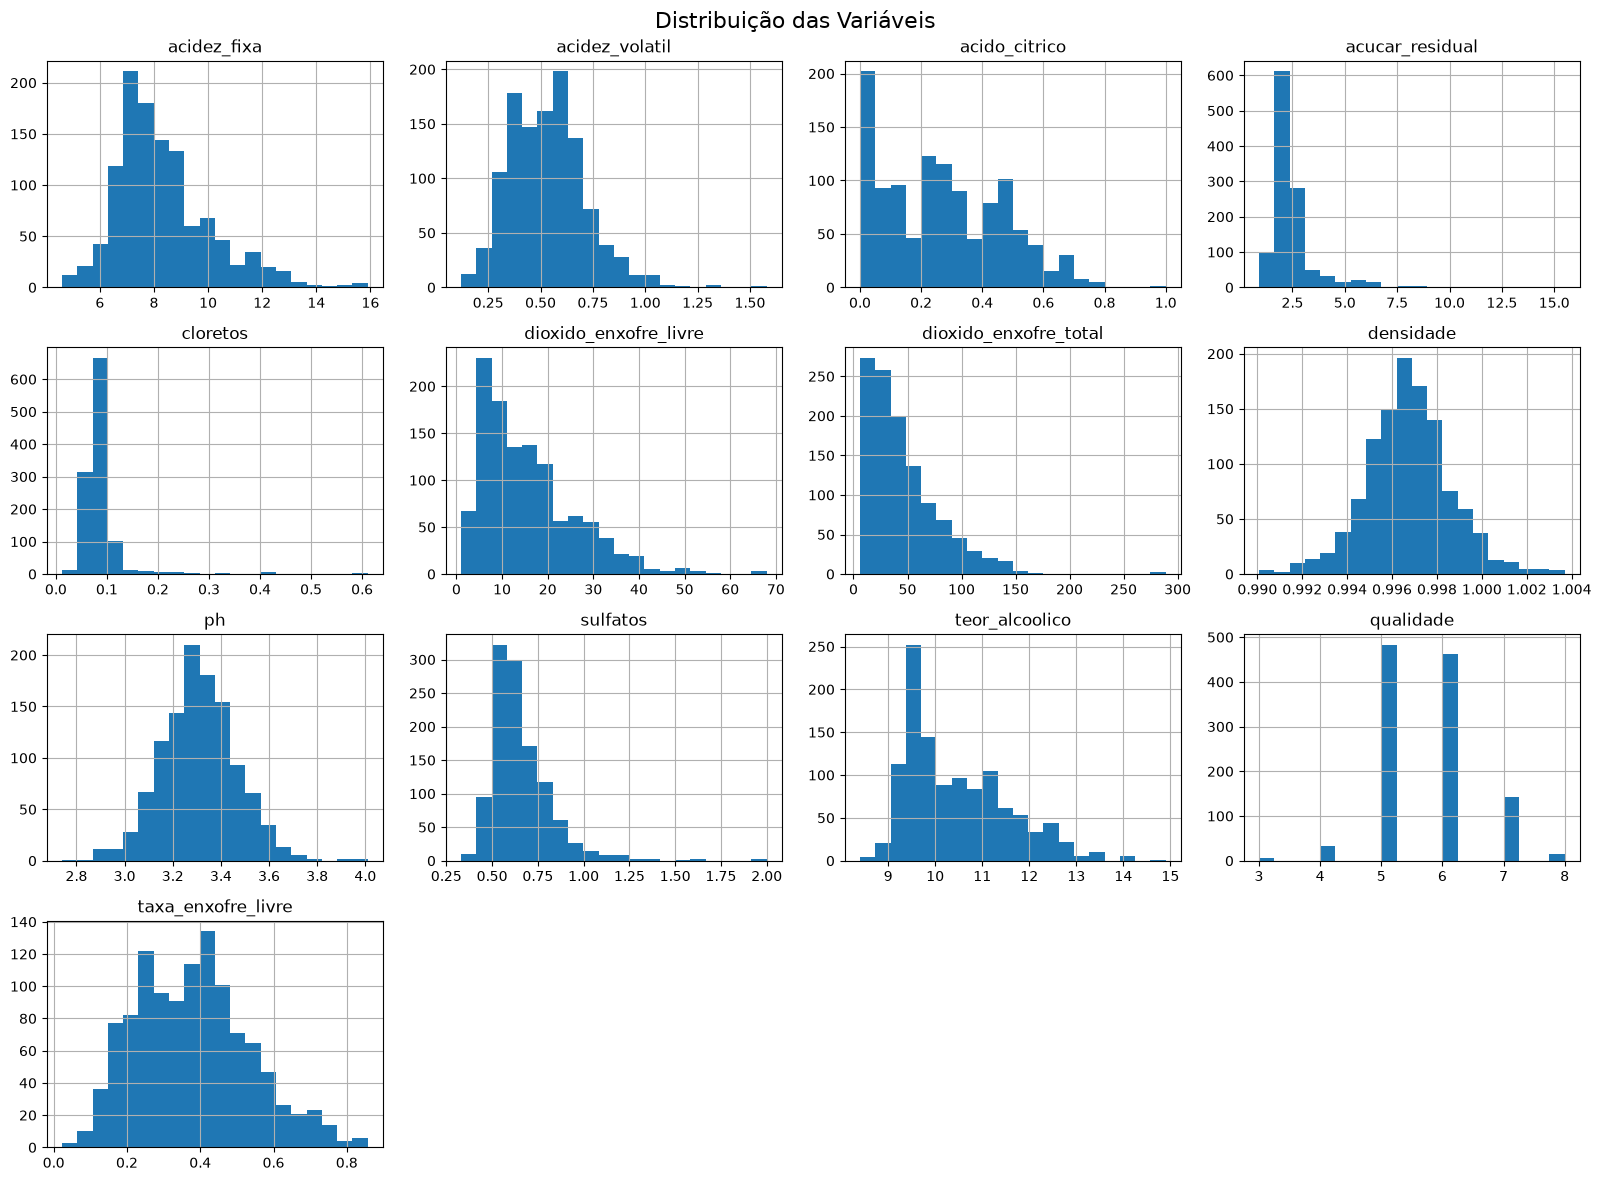

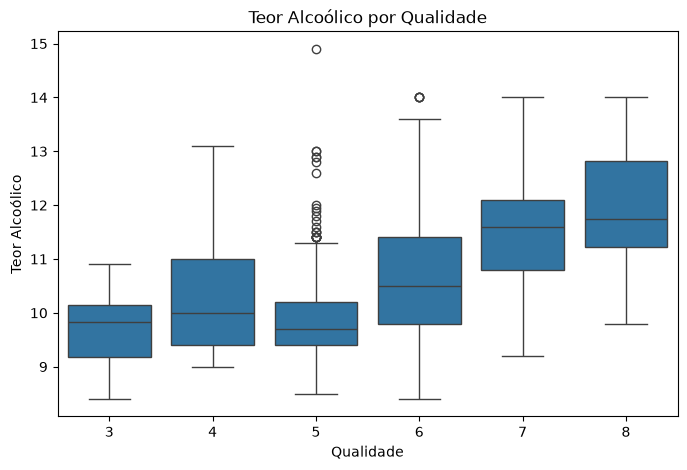

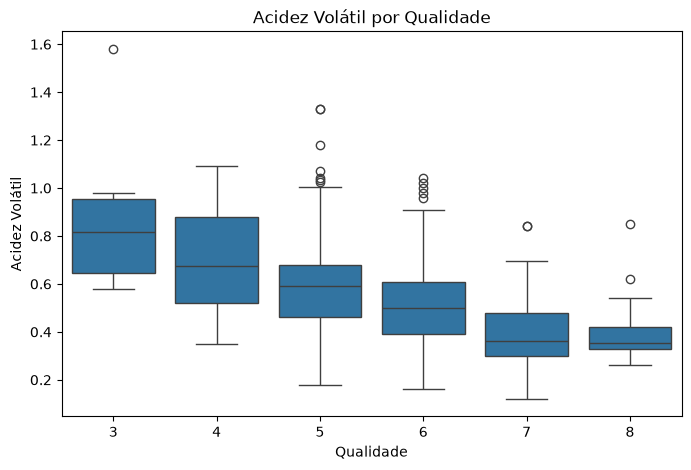

In [ ]:
print("PASSO 2: Análise Exploratória (EDA)")

df.info()

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='qualidade', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Quantidade de Vinhos por Nota de Qualidade')
plt.xlabel('Nota de Qualidade')
plt.ylabel('Quantidade de Vinhos')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['Id']).corr(),
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Físico-Químicas')
plt.show()

df.drop(columns=['Id', 'alta_qualidade']).hist(figsize=(16, 12), bins=20)
plt.suptitle('Distribuição das Variáveis', fontsize=16)
plt.tight_layout()
plt.show()

scaler_eda = StandardScaler()
df_padronizado = pd.DataFrame(
    scaler_eda.fit_transform(df.drop(columns=['alta_qualidade'])),
    columns=df.drop(columns=['alta_qualidade']).columns
)

plt.figure(figsize=(8, 5))
sns.boxplot(x='qualidade', y='teor_alcoolico', data=df)
plt.title('Teor Alcoólico por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Teor Alcoólico')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='qualidade', y='acidez_volatil', data=df)
plt.title('Acidez Volátil por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Acidez Volátil')
plt.show()

In [ ]:
print("PASSO 3: Pré-processamento")

df = df.dropna()

df['taxa_enxofre_livre'] = df['dioxido_enxofre_livre'] / df['dioxido_enxofre_total']

if np.isinf(df['taxa_enxofre_livre']).any() or df['taxa_enxofre_livre'].isna().any():
    df = df[~np.isinf(df['taxa_enxofre_livre'])]
    df = df.dropna(subset=['taxa_enxofre_livre'])
    print("Atenção: registros com divisão por zero foram removidos.")

X = df.drop(['alta_qualidade', 'qualidade', 'Id'], axis=1)
y = df['alta_qualidade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Engineering aplicada.")
print(f"Dados padronizados. Treino: {X_train_scaled.shape[0]} amostras | Teste: {X_test_scaled.shape[0]} amostras.")
print(f"Colunas usadas em X: {X.columns.tolist()}")

 PASSO 3: Pré-processamento
Feature Engineering aplicada.
Dados padronizados. Treino: 800 amostras | Teste: 343 amostras.
Colunas usadas em X: ['acidez_fixa', 'acidez_volatil', 'acido_citrico', 'acucar_residual', 'cloretos', 'dioxido_enxofre_livre', 'dioxido_enxofre_total', 'densidade', 'ph', 'sulfatos', 'teor_alcoolico', 'taxa_enxofre_livre']


In [73]:
print("PASSO 4: Treinando os Modelos")


modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)
modelo_lr.fit(X_train_scaled, y_train)


modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

print("Modelos treinados com sucesso!")

PASSO 4: Treinando os Modelos
Modelos treinados com sucesso!


In [74]:
print("--- PASSO 5: Avaliação e Comparação ---")

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

y_pred_log = modelo_lr.predict(X_test_scaled)
y_proba_log = modelo_lr.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = modelo_rf.predict(X_test_scaled)
y_proba_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame([
    {
        "Modelo": "Regressão Logística",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1-score": f1_score(y_test, y_pred_log),
        "ROC AUC": roc_auc_score(y_test, y_proba_log)
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf),
        "ROC AUC": roc_auc_score(y_test, y_proba_rf)
    }
])

results = results.round(3)
results

--- PASSO 5: Avaliação e Comparação ---


,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Regressão Logística,0.761,0.323,0.646,0.431,0.823
1,Random Forest,0.901,0.750,0.438,0.553,0.866


PASSO 6: Interpretação de Resultados


C:\Users\Victor\AppData\Local\Temp\ipykernel_11588\1805110558.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='Importancia', y='Variavel', palette='mako')


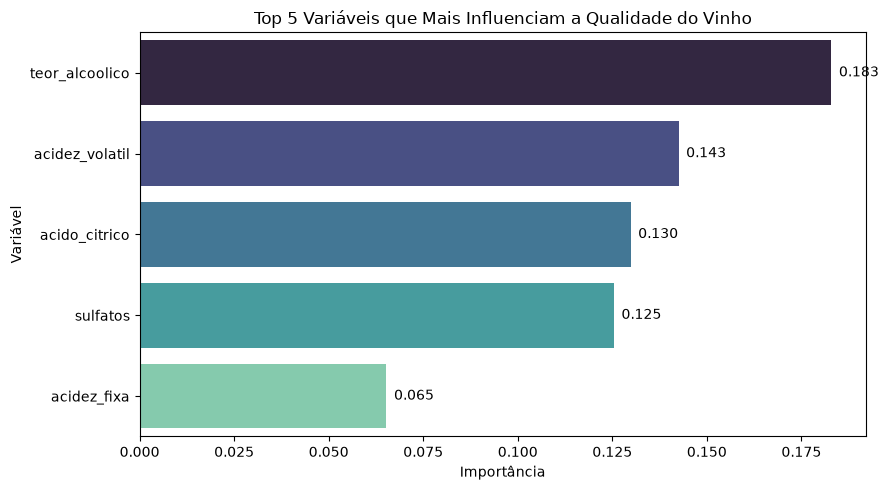

In [81]:
print("PASSO 6: Interpretação de Resultados")

df_importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

df_importancias = df_importancias[
    ~df_importancias['Variavel'].isin([
        'Id',
        'qualidade',
        'alta_qualidade',
        'quality',
        'quality_binary',
        'qualidade_binaria'
    ])
]

top5 = df_importancias.sort_values( by='Importancia', ascending=False).head(5)

plt.figure(figsize=(9,5))

sns.barplot(data=top5, x='Importancia', y='Variavel', palette='mako')

plt.title('Top 5 Variáveis que Mais Influenciam a Qualidade do Vinho')
plt.xlabel('Importância')
plt.ylabel('Variável')

for i, valor in enumerate(top5['Importancia']):
    plt.text(
        valor + 0.002,
        i,
        f'{valor:.3f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()